In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Load data
X_train = pd.read_csv('./data/processed/X_train.csv')
X_test = pd.read_csv('./data/processed/X_test.csv')
y_train = pd.read_csv('./data/processed/y_train.csv').squeeze()
test_ids = pd.read_csv('./data/processed/test_ids.csv')

# Final safety check - fill any NaN
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('Missing in X_train:', X_train.isnull().sum().sum())
print('Missing in X_test:', X_test.isnull().sum().sum())

X_train shape: (1458, 261)
X_test shape: (1459, 261)
y_train shape: (1458,)
Missing in X_train: 0
Missing in X_test: 0


In [2]:
def evaluate_model(model, X, y, model_name):
    scores = cross_val_score(model, X, y,
                             cv=5,
                             scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    print(f'{model_name}:')
    print(f'  RMSE scores: {rmse_scores.round(4)}')
    print(f'  Mean RMSE:   {rmse_scores.mean():.4f}')
    print(f'  Std RMSE:    {rmse_scores.std():.4f}')
    print()
    return rmse_scores.mean()

In [3]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10),
    'Lasso': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...')
    score = evaluate_model(model, X_train, y_train, name)
    results[name] = score

print('\n=== Final Results ===')
for name, score in sorted(results.items(), key=lambda x: x[1]):
    print(f'{name}: {score:.4f}')

Training Linear Regression...
Linear Regression:
  RMSE scores: [0.123  0.1346 0.1386 0.1099 0.1264]
  Mean RMSE:   0.1265
  Std RMSE:    0.0100

Training Ridge...
Ridge:
  RMSE scores: [0.12   0.1331 0.1311 0.1096 0.125 ]
  Mean RMSE:   0.1238
  Std RMSE:    0.0084

Training Lasso...
Lasso:
  RMSE scores: [0.115  0.1243 0.1254 0.1081 0.1148]
  Mean RMSE:   0.1175
  Std RMSE:    0.0065

Training Random Forest...
Random Forest:
  RMSE scores: [0.1378 0.1388 0.1436 0.1333 0.1382]
  Mean RMSE:   0.1383
  Std RMSE:    0.0033

Training XGBoost...
XGBoost:
  RMSE scores: [0.1327 0.1431 0.1485 0.1285 0.1358]
  Mean RMSE:   0.1377
  Std RMSE:    0.0072

Training LightGBM...
LightGBM:
  RMSE scores: [0.1228 0.1302 0.133  0.1216 0.1248]
  Mean RMSE:   0.1265
  Std RMSE:    0.0044


=== Final Results ===
Lasso: 0.1175
Ridge: 0.1238
LightGBM: 0.1265
Linear Regression: 0.1265
XGBoost: 0.1377
Random Forest: 0.1383


In [4]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_params,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1
)

print('Tuning XGBoost... this will take a few minutes')
xgb_grid.fit(X_train, y_train)

print('\nBest XGBoost params:', xgb_grid.best_params_)
print('Best XGBoost RMSE:', np.sqrt(-xgb_grid.best_score_).round(4))

Tuning XGBoost... this will take a few minutes
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best XGBoost RMSE: 0.1198


In [5]:
lgbm_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    lgbm_params,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1
)

print('Tuning LightGBM... this will take a few minutes')
lgbm_grid.fit(X_train, y_train)

print('\nBest LightGBM params:', lgbm_grid.best_params_)
print('Best LightGBM RMSE:', np.sqrt(-lgbm_grid.best_score_).round(4))

Tuning LightGBM... this will take a few minutes
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best LightGBM params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best LightGBM RMSE: 0.121


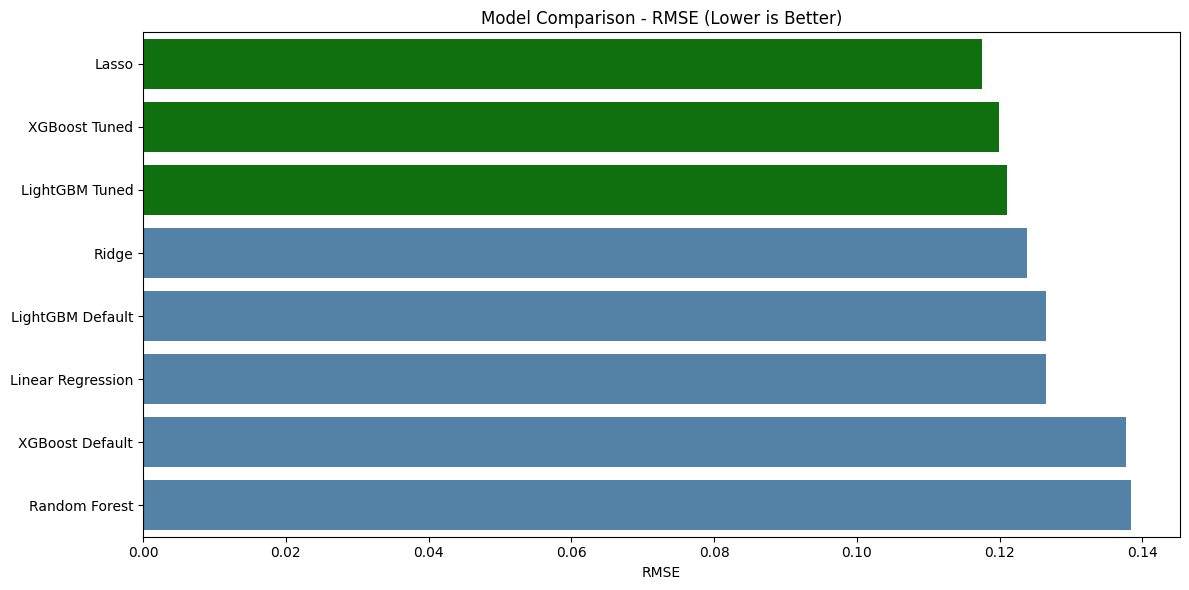


=== Final Model Rankings ===
Lasso: 0.1175
XGBoost Tuned: 0.1198
LightGBM Tuned: 0.1210
Ridge: 0.1238
LightGBM Default: 0.1265
Linear Regression: 0.1265
XGBoost Default: 0.1377
Random Forest: 0.1383


In [6]:
final_results = {
    'Lasso': results['Lasso'],
    'Ridge': results['Ridge'],
    'Linear Regression': results['Linear Regression'],
    'Random Forest': results['Random Forest'],
    'XGBoost Default': results['XGBoost'],
    'LightGBM Default': results['LightGBM'],
    'XGBoost Tuned': np.sqrt(-xgb_grid.best_score_),
    'LightGBM Tuned': np.sqrt(-lgbm_grid.best_score_)
}

final_results = dict(sorted(final_results.items(), key=lambda x: x[1]))

plt.figure(figsize=(12, 6))
colors = ['green' if 'Tuned' in k or k == 'Lasso' else 'steelblue'
          for k in final_results.keys()]
sns.barplot(x=list(final_results.values()),
            y=list(final_results.keys()),
            palette=colors)
plt.title('Model Comparison - RMSE (Lower is Better)')
plt.xlabel('RMSE')
plt.tight_layout()
plt.show()

print('\n=== Final Model Rankings ===')
for name, score in final_results.items():
    print(f'{name}: {score:.4f}')

In [7]:
# Train Lasso on full data
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train, y_train)

# Get predictions from all 3 models
lasso_preds = lasso_model.predict(X_test)
xgb_preds = xgb_grid.best_estimator_.predict(X_test)
lgbm_preds = lgbm_grid.best_estimator_.predict(X_test)

# Equal ensemble
ensemble_preds_log = (lasso_preds + xgb_preds + lgbm_preds) / 3
ensemble_preds_actual = np.expm1(ensemble_preds_log)

print('Sample ensemble predictions:')
print(ensemble_preds_actual[:5].round(0))
print('\nMin prediction:', ensemble_preds_actual.min().round(0))
print('Max prediction:', ensemble_preds_actual.max().round(0))
print('Mean prediction:', ensemble_preds_actual.mean().round(0))

Sample ensemble predictions:
[122455. 158983. 183150. 196238. 191014.]

Min prediction: 51087.0
Max prediction: 904283.0
Mean prediction: 178662.0


In [8]:
os.makedirs('./data/submission', exist_ok=True)
os.makedirs('./models', exist_ok=True)

# Lasso only submission
lasso_submission = pd.DataFrame({
    'Id': test_ids['Id'],
    'SalePrice': np.expm1(lasso_preds)
})
lasso_submission.to_csv('./data/submission/lasso_submission.csv', index=False)

# Ensemble submission
ensemble_submission = pd.DataFrame({
    'Id': test_ids['Id'],
    'SalePrice': ensemble_preds_actual
})
ensemble_submission.to_csv('./data/submission/ensemble_submission.csv', index=False)

# Save models
joblib.dump(lasso_model, './models/lasso_model.pkl')
joblib.dump(xgb_grid.best_estimator_, './models/xgb_model.pkl')
joblib.dump(lgbm_grid.best_estimator_, './models/lgbm_model.pkl')

print('All submissions saved!')
print('Submission files:', os.listdir('./data/submission'))
print('Model files:', os.listdir('./models'))

All submissions saved!
Submission files: ['.DS_Store', 'ensemble_submission.csv', 'submission.csv', 'lasso_submission.csv']
Model files: ['scaler.pkl', 'xgb_model.pkl', 'lgbm_model.pkl', 'lasso_model.pkl']
